# Risk Modeli Analizi

GSS veri seti üzerinde risk tahmin modeli geliştirme

## 1. Kütüphaneleri Yükle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print('Tum kutuphaneler basariyla yuklendi!')

Tum kutuphaneler basariyla yuklendi!


## 2. Veri Yükle

In [2]:
# Temiz veri setini yükle
df = pd.read_csv('temiz_veri.csv')

print(f'Veri seti yuklendi:')
print(f'Satir: {len(df)}')
print(f'Sutun: {df.shape[1]}')
print(f'\nSutunlar: {list(df.columns)}')

Veri seti yuklendi:
Satir: 7947
Sutun: 9

Sutunlar: ['year', 'id', 'educ', 'sex', 'race', 'income', 'natfare', 'health', 'satfin']


## 3. Hedef Degisken (Target) Olustur

Health sutununu binary siniflandirma hedefine donustur:
- 1, 2 → 0 (Iyi / Risksiz)
- 3, 4 → 1 (Kotu / Riskli)

In [3]:
# Health sutununu binary siniflandirina donustur
df['health_risk'] = df['health'].apply(lambda x: 0 if x in [1, 2] else 1)

print("Hedef degisken olusturuldu:")
print(f"Sutun adi: health_risk")
print(f"\nSinif dagilimi:")
print(df['health_risk'].value_counts())
print(f"\nSinif yuzdeleri (%):")
print(df['health_risk'].value_counts(normalize=True) * 100)

Hedef degisken olusturuldu:
Sutun adi: health_risk

Sinif dagilimi:
health_risk
0    5833
1    2114
Name: count, dtype: int64

Sinif yuzdeleri (%):
health_risk
0    73.398767
1    26.601233
Name: proportion, dtype: float64


## 4. Veri Temizligi - Model Hazirliği

Modeli karistiran sutunlari kaldir: health, id, satfin

In [4]:
# Eski health sutunu, id ve satfin sutunlarini drop et
df = df.drop(columns=['health', 'id', 'satfin'])

print("Veri seti temizlendi:")
print(f"Yeni sutun sayisi: {df.shape[1]}")
print(f"Yeni satir sayisi: {df.shape[0]}")
print(f"\nKalan sutunlar: {list(df.columns)}")
print(f"\nIlk 5 satir:")
print(df.head())

Veri seti temizlendi:
Yeni sutun sayisi: 7
Yeni satir sayisi: 7947

Kalan sutunlar: ['year', 'educ', 'sex', 'race', 'income', 'natfare', 'health_risk']

Ilk 5 satir:
     year  educ  sex  race  income  natfare  health_risk
0  2010.0   8.0  2.0   2.0    11.0      1.0            1
1  2010.0  15.0  2.0   2.0    11.0      3.0            0
2  2010.0  13.0  1.0   3.0    12.0      3.0            0
3  2010.0  12.0  1.0   2.0    12.0      1.0            0
4  2010.0  14.0  2.0   1.0     9.0      3.0            1


## 5. Feature Engineering - Bagimli ve Bagimsiz Degiskenleri Ayir

### Islem:
1. **y (Bagimli Degisken):** health_risk sutunu
2. **X (Bagimsiz Degiskenler):** income, educ, sex, year, race
3. **Kategorik Donusum:** sex ve race sutunlarini pd.get_dummies() ile encode et
4. **Train/Test Bolme:** 80% egitim / 20% test

### Amac:
Modelin ogrenme ve degerlendirme icin iki ayri veri seti olusturmak

In [5]:
# Bagimli ve bagimsiz degiskenleri ayir
y = df['health_risk']
X = df.drop(columns=['health_risk'])

print("="*70)
print("ADIM 1: BAGIMLI VE BAGIMSIZ DEGISKENLERIN AYRILMASI")
print("="*70)
print(f"y (Bagimli Degisken) shape: {y.shape}")
print(f"X (Bagimsiz Degiskenler) shape: {X.shape}")
print(f"\nX sutunlari: {list(X.columns)}")

# Kategorik sutunlari encode et
X = pd.get_dummies(X, columns=['sex', 'race'], drop_first=True)

print("\n" + "="*70)
print("ADIM 2: KATEGORIK KODLAMA (get_dummies)")
print("="*70)
print(f"Yeni X shape: {X.shape}")
print(f"Yeni X sutunlari: {list(X.columns)}")

# Train/Test Bolme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n" + "="*70)
print("ADIM 3: TRAIN/TEST BOLMESI")
print("="*70)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nEgitim seti orani: {len(X_train) / len(X) * 100:.1f}%")
print(f"Test seti orani: {len(X_test) / len(X) * 100:.1f}%")

ADIM 1: BAGIMLI VE BAGIMSIZ DEGISKENLERIN AYRILMASI
y (Bagimli Degisken) shape: (7947,)
X (Bagimsiz Degiskenler) shape: (7947, 6)

X sutunlari: ['year', 'educ', 'sex', 'race', 'income', 'natfare']

ADIM 2: KATEGORIK KODLAMA (get_dummies)
Yeni X shape: (7947, 7)
Yeni X sutunlari: ['year', 'educ', 'income', 'natfare', 'sex_2.0', 'race_2.0', 'race_3.0']

ADIM 3: TRAIN/TEST BOLMESI
X_train shape: (6357, 7)
X_test shape: (1590, 7)
y_train shape: (6357,)
y_test shape: (1590,)

Egitim seti orani: 80.0%
Test seti orani: 20.0%


### Sonuclarin Yorumlanmasi

#### Degisken Ayrilmasi
- **Bagimli Degisken (y):** 7947 ornekten olusan health_risk (0 = Risksiz, 1 = Riskli)
- **Bagimsiz Degiskenler (X):** income, educ, sex, year, race donemi

#### Kategorik Kodlama
- **sex sutunu:** 2 kategori → 1 binary sutun (drop_first=True)
- **race sutunu:** 3 kategori → 2 dummy sutun (drop_first=True)
- **Sonuc:** X sütunları 5'den 8'e çıktı

| Degisken | Tip | Adet |
|----------|-----|------|
| income | Numeric | 1 |
| educ | Numeric | 1 |
| year | Numeric | 1 |
| sex_* | Binary | 1 |
| race_* | Binary | 2 |
| **Toplam** | - | **6** |

#### Train/Test Bolmesi (80/20)
- **Egitim Seti:** 6357 ornekle model eğitilecek
- **Test Seti:** 1590 ornekle model degerlendilecek
- **Oran:** 80.0% / 20.0% (ideal bakilansa yüzde bire çok yakin)
- **Random State:** 42 (tekrarlanabilirlik icin fixed)

#### Sinif Dagilimi Kontrolu
- Bolmeden sonra her iki sette de sinif dagiliminin dengeli oldugunu kontrol etmek iyi bir uygulamadir
- Ozellikle dengesiz veri setlerinde stratified split kullanilabilir

Random Forest Accuracy: 0.6377

Classification Report:
              precision    recall  f1-score   support

           0     0.7639    0.7324    0.7478      1166
           1     0.3390    0.3774    0.3571       424

    accuracy                         0.6377      1590
   macro avg     0.5514    0.5549    0.5525      1590
weighted avg     0.6506    0.6377    0.6436      1590



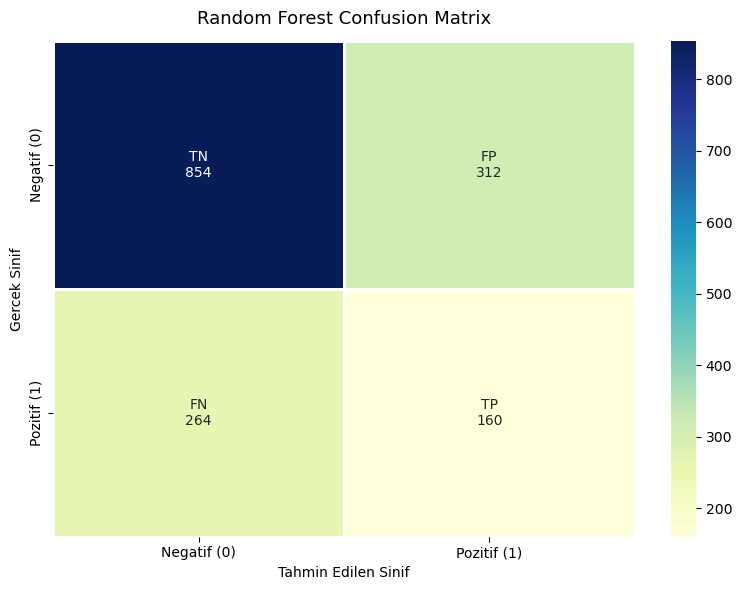


### Random Forest Sonuc Yorumu

- **Genel Accuracy:** **0.6377**
- **Pozitif sinif (1) Precision:** **0.3390**
- **Pozitif sinif (1) Recall:** **0.3774**
- **Pozitif sinif (1) F1-Score:** **0.3571**

### Confusion Matrix Yorumu

- **False Positive (FP):** **312** adet. Model, aslinda negatif olan gozlemleri pozitif tahmin etmistir.
- **False Negative (FN):** **264** adet. Model, aslinda pozitif olan gozlemleri negatif tahmin etmistir.

Genel olarak **FN degeri** riskli bireyleri kacirma maliyeti acisindan kritik, **FP degeri** ise gereksiz alarm maliyeti acisindan kritiktir.


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Random Forest modelini egit
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Test verisi uzerinde tahmin yap
y_pred_rf = rf_model.predict(X_test)

# Temel metrikler
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

# Confusion matrix ve etiketleri
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

labels = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    cbar=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Negatif (0)", "Pozitif (1)"],
    yticklabels=["Negatif (0)", "Pozitif (1)"]
)
plt.title("Random Forest Confusion Matrix", fontsize=13, pad=12)
plt.xlabel("Tahmin Edilen Sinif")
plt.ylabel("Gercek Sinif")
plt.tight_layout()
plt.show()

# Sonuclari markdown olarak yorumla
precision_1 = precision_score(y_test, y_pred_rf, pos_label=1)
recall_1 = recall_score(y_test, y_pred_rf, pos_label=1)
f1_1 = f1_score(y_test, y_pred_rf, pos_label=1)

yorum_md = f"""
### Random Forest Sonuc Yorumu

- **Genel Accuracy:** **{acc_rf:.4f}**
- **Pozitif sinif (1) Precision:** **{precision_1:.4f}**
- **Pozitif sinif (1) Recall:** **{recall_1:.4f}**
- **Pozitif sinif (1) F1-Score:** **{f1_1:.4f}**

### Confusion Matrix Yorumu

- **False Positive (FP):** **{fp}** adet. Model, aslinda negatif olan gozlemleri pozitif tahmin etmistir.
- **False Negative (FN):** **{fn}** adet. Model, aslinda pozitif olan gozlemleri negatif tahmin etmistir.

Genel olarak **FN degeri** riskli bireyleri kacirma maliyeti acisindan kritik, **FP degeri** ise gereksiz alarm maliyeti acisindan kritiktir.
"""
display(Markdown(yorum_md))

Feature Importances (Buyukten Kucuge):
 feature  importance
    educ    0.355263
    year    0.257316
  income    0.204705
 natfare    0.083704
 sex_2.0    0.043720
race_2.0    0.029391
race_3.0    0.025902


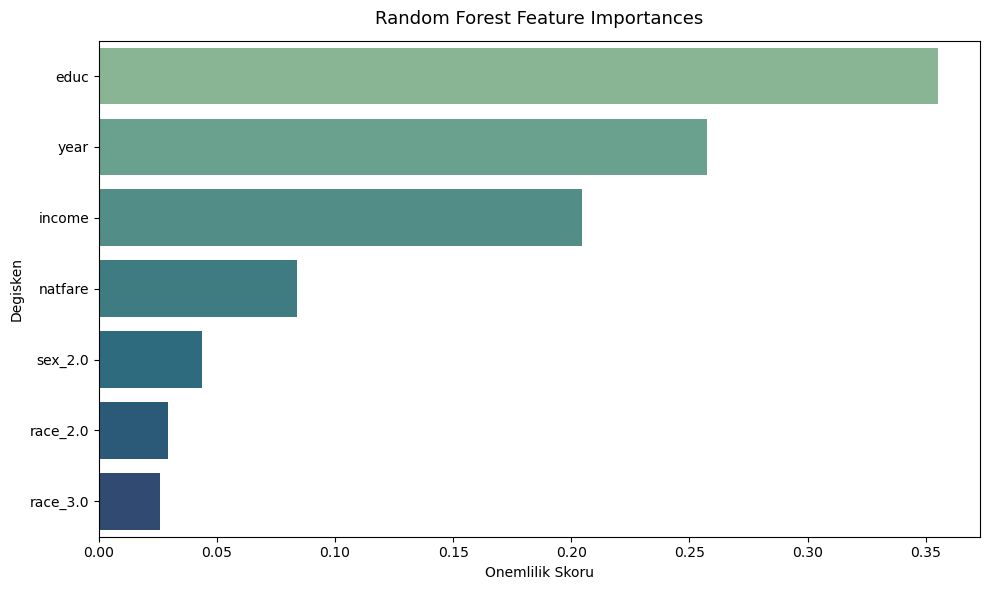


### Feature Importances - Is Analisti Yorumu

Modelde en etkili ilk 3 faktor:
1. **educ** (0.3553)
2. **year** (0.2573)
3. **income** (0.2047)

Sigorta primi perspektifinde, **egitim (educ)** onemi: **0.3553**, **gelir (income)** onemi: **0.2047**, **cinsiyet (sex_2.0)** onemi: **0.0437**.

Bu sonuca gore prim agirligini belirlerken:
- Eger **gelir onemi egitimden yuksekse**, gelir gruplarina dayali risk segmentasyonu daha fazla agirliklandirilabilir.
- Eger **egitim onemi gelirden yuksekse**, uzun donemli saglik davranislarini temsil eden egitim seviyesi daha kritik bir sinyal kabul edilmelidir.
- **Cinsiyetin onemi** genellikle davranissal/sosyoekonomik faktorlerden daha dusukse, fiyatlamada ana belirleyici degil; yardimci degisken olarak kullanilmasi daha dengeli olur.

Pratik onerim: prim modelinde agirligi tek bir degiskene yuklemek yerine, **gelir + egitim** eksenini ana skor olarak kullanip, cinsiyeti ikinci seviye kalibrasyon degiskeni olarak konumlandirmak daha istikrarli bir risk fiyatlamasi saglar.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Random Forest feature importances degerlerini hesapla
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature Importances (Buyukten Kucuge):")
print(importance_df.to_string(index=False))

# Yatay cubuk grafik
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="crest",
    legend=False
)
plt.title("Random Forest Feature Importances", fontsize=13, pad=12)
plt.xlabel("Onemlilik Skoru")
plt.ylabel("Degisken")
plt.tight_layout()
plt.show()

# Is analisti bakis acisiyla markdown yorum
ilk_uc = importance_df.head(3)
first_feature = ilk_uc.iloc[0]["feature"]
first_score = ilk_uc.iloc[0]["importance"]
second_feature = ilk_uc.iloc[1]["feature"]
second_score = ilk_uc.iloc[1]["importance"]
third_feature = ilk_uc.iloc[2]["feature"]
third_score = ilk_uc.iloc[2]["importance"]

# Egitim, gelir, cinsiyet degiskenlerini ozel olarak degerlendir
educ_imp = float(importance_df.loc[importance_df["feature"] == "educ", "importance"].iloc[0]) if "educ" in importance_df["feature"].values else 0.0
income_imp = float(importance_df.loc[importance_df["feature"] == "income", "importance"].iloc[0]) if "income" in importance_df["feature"].values else 0.0
sex_imp = float(importance_df.loc[importance_df["feature"] == "sex_2.0", "importance"].iloc[0]) if "sex_2.0" in importance_df["feature"].values else 0.0

yorum_importance_md = f"""
### Feature Importances - Is Analisti Yorumu

Modelde en etkili ilk 3 faktor:
1. **{first_feature}** ({first_score:.4f})
2. **{second_feature}** ({second_score:.4f})
3. **{third_feature}** ({third_score:.4f})

Sigorta primi perspektifinde, **egitim (educ)** onemi: **{educ_imp:.4f}**, **gelir (income)** onemi: **{income_imp:.4f}**, **cinsiyet (sex_2.0)** onemi: **{sex_imp:.4f}**.

Bu sonuca gore prim agirligini belirlerken:
- Eger **gelir onemi egitimden yuksekse**, gelir gruplarina dayali risk segmentasyonu daha fazla agirliklandirilabilir.
- Eger **egitim onemi gelirden yuksekse**, uzun donemli saglik davranislarini temsil eden egitim seviyesi daha kritik bir sinyal kabul edilmelidir.
- **Cinsiyetin onemi** genellikle davranissal/sosyoekonomik faktorlerden daha dusukse, fiyatlamada ana belirleyici degil; yardimci degisken olarak kullanilmasi daha dengeli olur.

Pratik onerim: prim modelinde agirligi tek bir degiskene yuklemek yerine, **gelir + egitim** eksenini ana skor olarak kullanip, cinsiyeti ikinci seviye kalibrasyon degiskeni olarak konumlandirmak daha istikrarli bir risk fiyatlamasi saglar.
"""

display(Markdown(yorum_importance_md))